In [1]:
import pandas as pd
import numpy as np
from decimal import Decimal, ROUND_HALF_UP
from xgboost import XGBClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
#case_df = pd.read_csv('s3://ads508-s3/time_series_covid19_confirmed_US.csv')
case_df = pd.read_csv('/Users/AkshatPatni/Documents/USD MSADS Course Content/ADS-508/ADS_cloud/time_series_covid19_confirmed_US.csv')
case_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20,9/22/20,9/23/20,9/24/20,9/25/20,9/26/20,9/27/20,9/28/20,9/29/20,9/30/20,10/1/20,10/2/20,10/3/20,10/4/20,10/5/20,10/6/20,10/7/20,10/8/20,10/9/20,10/10/20,10/11/20,10/12/20,10/13/20,10/14/20,10/15/20,10/16/20,10/17/20,10/18/20,10/19/20,10/20/20,10/21/20,10/22/20,10/23/20,10/24/20,10/25/20,10/26/20,10/27/20,10/28/20,10/29/20,10/30/20,10/31/20,11/1/20,11/2/20,11/3/20,11/4/20,11/5/20,11/6/20,11/7/20,11/8/20,11/9/20,11/10/20,11/11/20,11/12/20,11/13/20,11/14/20,11/15/20,11/16/20,11/17/20,11/18/20,11/19/20,11/20/20,11/21/20,11/22/20,11/23/20,11/24/20,11/25/20,11/26/20,11/27/20,11/28/20,11/29/20,11/30/20,12/1/20,12/2/20,12/3/20,12/4/20,12/5/20,12/6/20,12/7/20,12/8/20,12/9/20,12/10/20,12/11/20,12/12/20,12/13/20,12/14/20,12/15/20,12/16/20,12/17/20,12/18/20,12/19/20,12/20/20,12/21/20,12/22/20,12/23/20,12/24/20,12/25/20,12/26/20,12/27/20,12/28/20,12/29/20,12/30/20,12/31/20,1/1/21,1/2/21,1/3/21,1/4/21,1/5/21,1/6/21,1/7/21,1/8/21,1/9/21,1/10/21,1/11/21,1/12/21,1/13/21,1/14/21,1/15/21,1/16/21,1/17/21,1/18/21,1/19/21,1/20/21,1/21/21,1/22/21,1/23/21,1/24/21,1/25/21,1/26/21,1/27/21,1/28/21,1/29/21,1/30/21,1/31/21,2/1/21,2/2/21,2/3/21,2/4/21,2/5/21,2/6/21,2/7/21,2/8/21,2/9/21,2/10/21,2/11/21,2/12/21,2/13/21,2/14/21,2/15/21,2/16/21,2/17/21,2/18/21,2/19/21,2/20/21,2/21/21,2/22/21,2/23/21,2/24/21,2/25/21,2/26/21,2/27/21,2/28/21,3/1/21,3/2/21,3/3/21,3/4/21,3/5/21,3/6/21,3/7/21,3/8/21,3/9/21,3/10/21,3/11/21,3/12/21,3/13/21,3/14/21,3/15/21,3/16/21,3/17/21,3/18/21,3/19/21,3/20/21,3/21/21,3/22/21,3/23/21,3/24/21,3/25/21,3/26/21,3/27/21,3/28/21,3/29/21,3/30/21,3/31/21,4/1/21,4/2/21,4/3/21,4/4/21,4/5/21,4/6/21,4/7/21,4/8/21,4/9/21,4/10/21,4/11/21,4/12/21,4/13/21,4/14/21,4/15/21,4/16/21,4/17/21,4/18/21,4/19/21,4/20/21,4/21/21,4/22/21,4/23/21,4/24/21,4/25/21,4/26/21,4/27/21,4/28/21,4/29/21,4/30/21,5/1/21,5/2/21,5/3/21,5/4/21,5/5/21,5/6/21,5/7/21,5/8/21,5/9/21,5/10/21,5/11/21,5/12/21,5/13/21,5/14/21,5/15/21,5/16/21,5/17/21,5/18/21,5/19/21,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21,5/30/21,5/31/2

In [3]:
#death_df = pd.read_csv('s3://ads508-s3/time_series_covid19_deaths_US.csv')
death_df = pd.read_csv('/Users/AkshatPatni/Documents/USD MSADS Course Content/ADS-508/ADS_cloud/time_series_covid19_deaths_US.csv')
death_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Population,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20,9/22/20,9/23/20,9/24/20,9/25/20,9/26/20,9/27/20,9/28/20,9/29/20,9/30/20,10/1/20,10/2/20,10/3/20,10/4/20,10/5/20,10/6/20,10/7/20,10/8/20,10/9/20,10/10/20,10/11/20,10/12/20,10/13/20,10/14/20,10/15/20,10/16/20,10/17/20,10/18/20,10/19/20,10/20/20,10/21/20,10/22/20,10/23/20,10/24/20,10/25/20,10/26/20,10/27/20,10/28/20,10/29/20,10/30/20,10/31/20,11/1/20,11/2/20,11/3/20,11/4/20,11/5/20,11/6/20,11/7/20,11/8/20,11/9/20,11/10/20,11/11/20,11/12/20,11/13/20,11/14/20,11/15/20,11/16/20,11/17/20,11/18/20,11/19/20,11/20/20,11/21/20,11/22/20,11/23/20,11/24/20,11/25/20,11/26/20,11/27/20,11/28/20,11/29/20,11/30/20,12/1/20,12/2/20,12/3/20,12/4/20,12/5/20,12/6/20,12/7/20,12/8/20,12/9/20,12/10/20,12/11/20,12/12/20,12/13/20,12/14/20,12/15/20,12/16/20,12/17/20,12/18/20,12/19/20,12/20/20,12/21/20,12/22/20,12/23/20,12/24/20,12/25/20,12/26/20,12/27/20,12/28/20,12/29/20,12/30/20,12/31/20,1/1/21,1/2/21,1/3/21,1/4/21,1/5/21,1/6/21,1/7/21,1/8/21,1/9/21,1/10/21,1/11/21,1/12/21,1/13/21,1/14/21,1/15/21,1/16/21,1/17/21,1/18/21,1/19/21,1/20/21,1/21/21,1/22/21,1/23/21,1/24/21,1/25/21,1/26/21,1/27/21,1/28/21,1/29/21,1/30/21,1/31/21,2/1/21,2/2/21,2/3/21,2/4/21,2/5/21,2/6/21,2/7/21,2/8/21,2/9/21,2/10/21,2/11/21,2/12/21,2/13/21,2/14/21,2/15/21,2/16/21,2/17/21,2/18/21,2/19/21,2/20/21,2/21/21,2/22/21,2/23/21,2/24/21,2/25/21,2/26/21,2/27/21,2/28/21,3/1/21,3/2/21,3/3/21,3/4/21,3/5/21,3/6/21,3/7/21,3/8/21,3/9/21,3/10/21,3/11/21,3/12/21,3/13/21,3/14/21,3/15/21,3/16/21,3/17/21,3/18/21,3/19/21,3/20/21,3/21/21,3/22/21,3/23/21,3/24/21,3/25/21,3/26/21,3/27/21,3/28/21,3/29/21,3/30/21,3/31/21,4/1/21,4/2/21,4/3/21,4/4/21,4/5/21,4/6/21,4/7/21,4/8/21,4/9/21,4/10/21,4/11/21,4/12/21,4/13/21,4/14/21,4/15/21,4/16/21,4/17/21,4/18/21,4/19/21,4/20/21,4/21/21,4/22/21,4/23/21,4/24/21,4/25/21,4/26/21,4/27/21,4/28/21,4/29/21,4/30/21,5/1/21,5/2/21,5/3/21,5/4/21,5/5/21,5/6/21,5/7/21,5/8/21,5/9/21,5/10/21,5/11/21,5/12/21,5/13/21,5/14/21,5/15/21,5/16/21,5/17/21,5/18/21,5/19/21,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21,5/3

In [4]:
case_df.columns

Index(['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State',
       'Country_Region', 'Lat', 'Long_',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1154)

In [5]:
print(case_df.shape)
print(death_df.shape)

(3342, 1154)
(3342, 1155)


In [6]:
case_df = case_df.drop(
    columns=['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Country_Region', 'Combined_Key'],
    errors='ignore'
)

# Drop rows where 'Admin2' is missing
case_df = case_df.dropna(subset=['Admin2'])

# Reshape the dataframe from wide to long
case_df = pd.melt(
    case_df,
    id_vars=['Admin2', 'Province_State', 'Lat', 'Long_'],
    var_name='Date',
    value_name='Cases'  # Use different name to avoid conflict
)

# Convert 'Date' column with explicit format
case_df['Date'] = pd.to_datetime(case_df['Date'], format='%m/%d/%y')

# Optimize memory usage
case_df['Cases'] = pd.to_numeric(case_df['Cases'], downcast='integer')
case_df['Lat'] = np.round(case_df['Lat'], 3)
case_df['Long_'] = np.round(case_df['Long_'], 3)
case_df['Admin2'] = case_df['Admin2'].astype('category')
case_df['Province_State'] = case_df['Province_State'].astype('category')

# Resample weekly death data
case_df.set_index('Date', inplace=True)
case_resample = case_df.groupby(
    ['Admin2', 'Lat', 'Long_', 'Province_State'],
    observed=False
).resample('W')['Cases'].mean().reset_index()

# Final cleanup
case_resample.reset_index(drop=True, inplace=True)

In [7]:
death_df = death_df.drop(
    columns=['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Country_Region', 'Combined_Key'],
    errors='ignore'
)

# Drop rows where 'Admin2' is missing
death_df = death_df.dropna(subset=['Admin2'])

# Reshape the DataFrame from wide to long
death_df = pd.melt(
    death_df,
    id_vars=['Admin2', 'Province_State', 'Lat', 'Long_', 'Population'],
    var_name='Date',
    value_name='Deaths'
)

# Convert 'Date' column with explicit format
death_df['Date'] = pd.to_datetime(death_df['Date'], format='%m/%d/%y')

# Optimize memory usage
death_df['Deaths'] = pd.to_numeric(death_df['Deaths'], downcast='integer')
death_df['Population'] = pd.to_numeric(death_df['Population'], downcast='integer')
death_df['Lat'] = np.round(death_df['Lat'], 3)
death_df['Long_'] = np.round(death_df['Long_'], 3)
death_df['Admin2'] = death_df['Admin2'].astype('category')
death_df['Province_State'] = death_df['Province_State'].astype('category')

# Resample weekly confirmed data
death_df.set_index('Date', inplace=True)
death_resample = death_df.groupby(
    ['Admin2', 'Lat', 'Long_', 'Province_State', 'Population'],
    observed=False
).resample('W')['Deaths'].mean().reset_index()

# Final cleanup
death_resample.reset_index(drop=True, inplace=True)

In [8]:
death_staging = death_resample[['Date', 'Admin2', 'Lat', 'Long_', 'Province_State', 'Deaths', 'Population']]

# Merge on full key set to avoid many-to-many explosion
base_df = pd.merge(
    case_resample,
    death_staging,
    on=['Date', 'Admin2', 'Lat', 'Long_', 'Province_State'],
    how='left'
)

base_df.sort_values(['Admin2', 'Date'], inplace = True)
base_df.reset_index(inplace=True, drop = True)
base_df.head()

,Admin2,Lat,Long_,Province_State,Date,Cases,Deaths,Population
0,Abbeville,34.223,-82.462,South Carolina,2020-01-26,0.0,0.0,24527
1,Abbeville,34.223,-82.462,South Carolina,2020-02-02,0.0,0.0,24527
2,Abbeville,34.223,-82.462,South Carolina,2020-02-09,0.0,0.0,24527
3,Abbeville,34.223,-82.462,South Carolina,2020-02-16,0.0,0.0,24527
4,Abbeville,34.223,-82.462,South Carolina,2020-02-23,0.0,0.0,24527


In [9]:
base_df.shape

(547104, 8)

In [10]:
print(base_df['Date'].min())
print(base_df['Date'].max())

2020-01-26 00:00:00
2023-03-12 00:00:00


In [11]:
"""The following are the top 10 states with the most covid deaths between 01-26-2020 and 03-12-2023... The numbers are not adding up properly need to look more into this"""
(
    base_df
    .groupby('Province_State', observed=False)['Deaths']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Province_State
California      9.399045e+06
Texas           8.797454e+06
New York        8.336092e+06
Florida         7.390842e+06
Pennsylvania    4.580452e+06
Illinois        4.052106e+06
New Jersey      4.029872e+06
Georgia         3.765174e+06
Ohio            3.742557e+06
Michigan        3.667562e+06
Name: Deaths, dtype: float64

## Feature Engineering

In [13]:
#Avg Case Stats by State

base_df['Avg State Cases'] = base_df.groupby(['Date', 'Province_State'])['Cases'].transform('mean')
base_df['Avg State Deaths'] = base_df.groupby(['Date', 'Province_State'])['Deaths'].transform('mean')

In [14]:
windows = {
    '1_month': 4,
    '2_month': 8,
    '3_month': 12
}

# Calculate rolling averages for each city
for window_name, window_size in windows.items():
    base_df[f'cases_{window_name}_avg'] = (
        base_df.groupby('Admin2')['Cases']
        .transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
    )
    base_df[f'deaths_{window_name}_avg'] = (
        base_df.groupby('Admin2')['Deaths']
        .transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
    )


In [15]:
base_df.sort_values(['Admin2', 'Date'], inplace = True)
base_df.reset_index(inplace=True, drop = True)

for lag in [1, 2, 3]:
    base_df[f'lag_{lag}_week_cases'] = (
        base_df
        .groupby('Admin2')['Cases']
        .shift(lag)
    )
    base_df[f'lag_{lag}_week_deaths'] = (
        base_df
        .groupby('Admin2')['Deaths']
        .shift(lag)
    )


In [16]:
numerical_cols = base_df.select_dtypes(include='number').columns.drop(['Population', 'Lat', 'Long_'])

# Create per-capita versions of all stats
base_df[[f"{col}_per_capita" for col in numerical_cols]] = (
    base_df[numerical_cols].div(base_df['Population'], axis=0)
)


In [17]:
base_df['weekofyear'] = base_df['Date'].dt.isocalendar().week
base_df['month'] = base_df['Date'].dt.month
base_df['year'] = base_df['Date'].dt.year

In [18]:
# Create shifted per capita values for comparison
base_df['nextweek_case_rate'] = base_df.groupby('Admin2')['Cases_per_capita'].shift(-1)

# Create binary target indicator 
#base_df['is_hotspot'] = (base_df['nextweek_case_rate'] >= 0.1).astype(int)
base_df['is_hotspot'] = ((base_df['nextweek_case_rate'] > base_df['Cases_per_capita']) & (base_df['nextweek_case_rate'] >= 0.1)).astype(int)

base_df = base_df.drop(columns=['nextweek_case_rate'])

In [19]:
base_df[10000:10100]

,Admin2,Lat,Long_,Province_State,Date,Cases,Deaths,Population,Avg State Cases,Avg State Deaths,cases_1_month_avg,deaths_1_month_avg,cases_2_month_avg,deaths_2_month_avg,cases_3_month_avg,deaths_3_month_avg,lag_1_week_cases,lag_1_week_deaths,lag_2_week_cases,lag_2_week_deaths,lag_3_week_cases,lag_3_week_deaths,Cases_per_capita,Deaths_per_capita,Avg State Cases_per_capita,Avg State Deaths_per_capita,cases_1_month_avg_per_capita,deaths_1_month_avg_per_capita,cases_2_month_avg_per_capita,deaths_2_month_avg_per_capita,cases_3_month_avg_per_capita,deaths_3_month_avg_per_capita,lag_1_week_cases_per_capita,lag_1_week_deaths_per_capita,lag_2_week_cases_per_capita,lag_2_week_deaths_per_capita,lag_3_week_cases_per_capita,lag_3_week_deaths_per_capita,weekofyear,month,year,is_hotspot
10000,Amelia,37.341,-77.986,Virginia,2023-02-19,3552.857143,64.000000,13145,16854.118519,174.662434,3532.642857,64.000000,3492.589286,63.732143,3449.333333,63.250000,3538.857143,64.000000,3529.142857,64.000000,3509.714286,64.000000,0.270282,0.004869,1.282170,0.013287,0.268744,0.004869,0.265697,0.004848,0.262406,0.004812,0.269217,0.004869,0.268478,0.004869,0.267000,0.004869,7,2,2023,1
10001,Amelia,37.341,-77.986,Virginia,2023-02-26,3564.428571,64.000000,13145,16899.039153,175.004233,3546.321429,64.000000,3511.982143,63.857143,3468.130952,63.440476,3552.857143,64.000000,3538.857143,64.000000,3529.142857,64.000000,0.271162,0.004869,1.285587,0.013313,0.269785,0.004869,0.267172,0.004858,0.263837,0.004826,0.270282,0.004869,0.269217,0.004869,0.268478,0.004869,8,2,2023,1
10002,Amelia,37.341,-77.986,Virginia,2023-03-05,3571.142857,64.000000,13145,16938.461376,175.157672,3556.821429,64.000000,3529.428571,63.982143,3486.535714,63.607143,3564.428571,64.000000,3552.857143,64.000000,3538.857143,64.000000,0.271673,0.004869,1.288586,0.013325,0.270584,0.004869,0.268500,0.004867,0.265237,0.004839,0.271162,0.004869,0.270282,0.004869,0.269217,0.004869,9,3,2023,1
10003,Amelia,37.341,-77.986,Virginia,2023-03-12,3579.500000,64.000000,13145,16969.059259,175.272222,3566.982143,64.000000,3542.455357,64.000000,3504.053571,63.738095,3571.142857,64.000000,3564.428571,64.000000,3552.857143,64.000000,0.272309,0.004869,1.290914,0.013334,0.271357,0.004869,0.269491,0.004869,0.266569,0.004849,0.271673,0.004869,0.271162,0.004869,0.270282,0.004869,10,3,2023,0
10004,Amherst,37.603,-79.145,Virginia,2020-01-26,0.000000,0.000000,31605,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,4,1,2020,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10095,Amherst,37.603,-79.145,Virginia,2021-10-24,4286.285714,55.714286,31605,6757.742857,100.779894,4190.821429,53.607143,3988.392857,49.142857,3723.309524,46.238095,4233.000000,54.142857,4162.571429,53.000000,4081.428571,51.571429,0.135620,0.001763,0.213819,0.003189,0.132600,0.001696,0.126195,0.001555,0.117808,0.001463,0.133935,0.001713,0.131706,0.001677,0.129139,0.001632,42,10,2021,1
10096,Amherst,37.603,-79.145,Virginia,2021-10-31,4337.857143,57.000000,31605,6833.615873,102.598942,4254.928571,54.964286,4092.589286,51.035714,3827.035714,47.654762,4286.285714,55.714286,4233.000000,54.142857,4162.571429,53.000000,0.137252,0.001804,0.216219,0.003246,0.134628,0.001739,0.129492,0.001615,0.121090,0.001508,0.135620,0.001763,0.133935,0.001713,0.131706,0.001677,43,10,2021,1
10097,Amherst,37.603,-79.145,Virginia,2021-11-07,4373.000000,58.142857,31605,6900.233862,104.253968,4307.535714,56.250000,4174.321429,52.857143,3929.869048,49.166667,4337.857143,57.000000,4286.285714,55.714286,4233.000000,54.142857,0.138364,0.001840,0.218327,0.003299,0.136293,0.001780,0.132078,0.001672,0.124343,0.001556,0.137252,0.001804,0.135620,0.001763,0.133935,0.001713,44,11,2021,1
10098,Amherst,37.603,-79.145,Virgini

In [20]:
base_df['is_hotspot'].value_counts(normalize=True)

is_hotspot
0    0.599096
1    0.400904
Name: proportion, dtype: float64

## Model Implementation and Testing

In [22]:
df = base_df.dropna()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

#Create monthly strata 
df['time_period'] = df['Date'].dt.to_period('Q')

train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df[['Admin2', 'time_period']],  # Combine city and time strata
    random_state=42
)

df = df.drop(columns=['time_period'])

feature_cols = []

for col in df.columns:
    
    if col not in ['Admin2', 'Province_State', 'Date', 'is_hotspot']:
        feature_cols.append(col)

X_train = train_df[feature_cols]
y_train = train_df['is_hotspot']

X_test = test_df[feature_cols]
y_test = test_df['is_hotspot']



Training XGBoost...

--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     60344
           1       0.95      0.96      0.95     44220

    accuracy                           0.96    104564
   macro avg       0.96      0.96      0.96    104564
weighted avg       0.96      0.96      0.96    104564



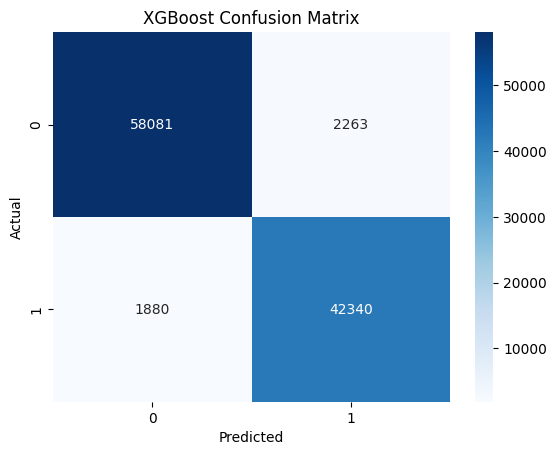

ROC AUC: 0.9917


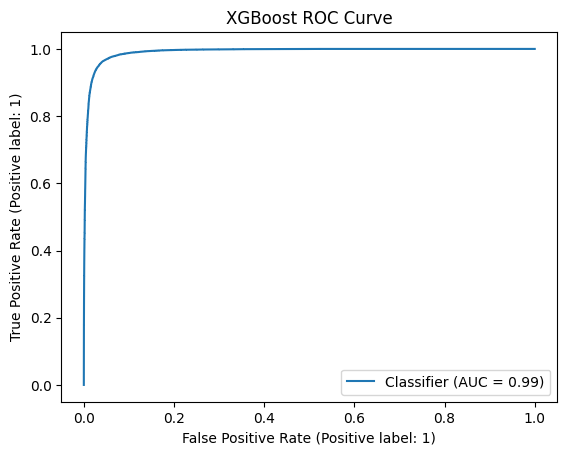

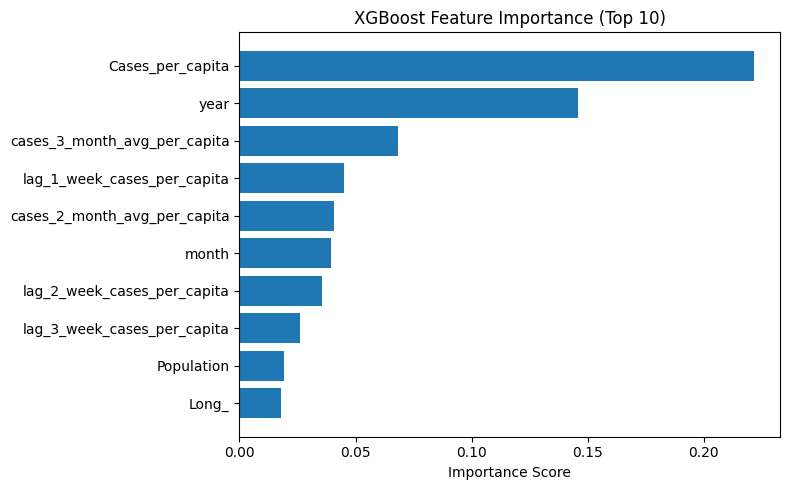


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 175116, number of negative: 243138
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8997
[LightGBM] [Info] Number of data points in the train set: 418254, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.418683 -> initscore=-0.328181
[LightGBM] [Info] Start training from score -0.328181

--- LightGBM Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     60344
           1       0.90      0.90      0.90     44220

    accuracy                           0.91    104564
   macro avg       0.91      0.91      0.91    104564
weighted avg       0.91      0.91      0.91    104564



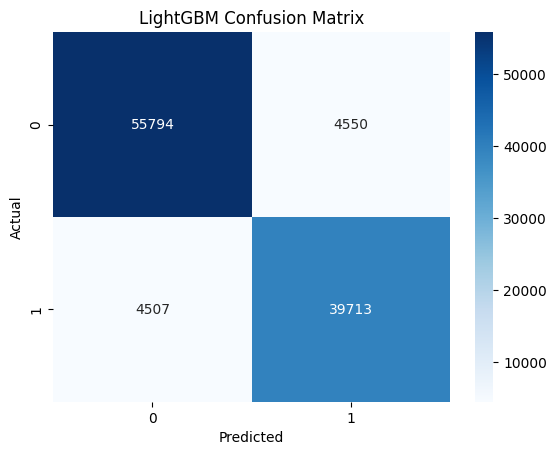

ROC AUC: 0.9745


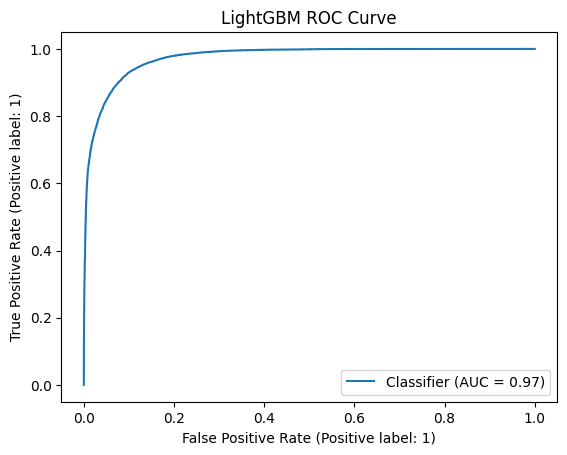

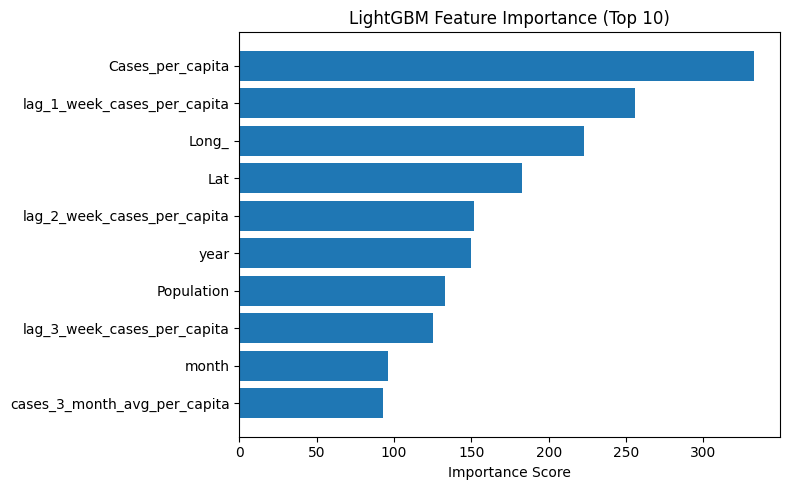


Training DecisionTree...

--- DecisionTree Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     60344
           1       0.97      0.97      0.97     44220

    accuracy                           0.97    104564
   macro avg       0.97      0.97      0.97    104564
weighted avg       0.97      0.97      0.97    104564



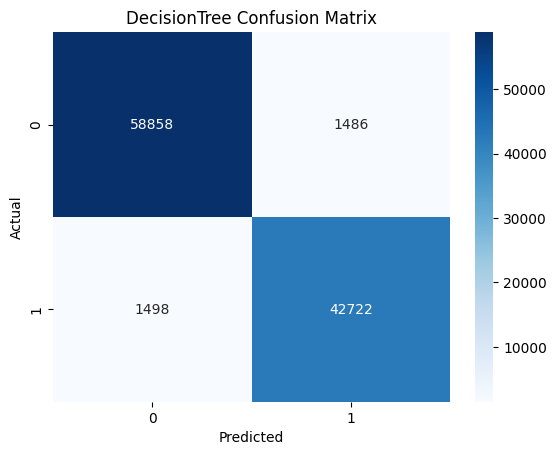

ROC AUC: 0.9707


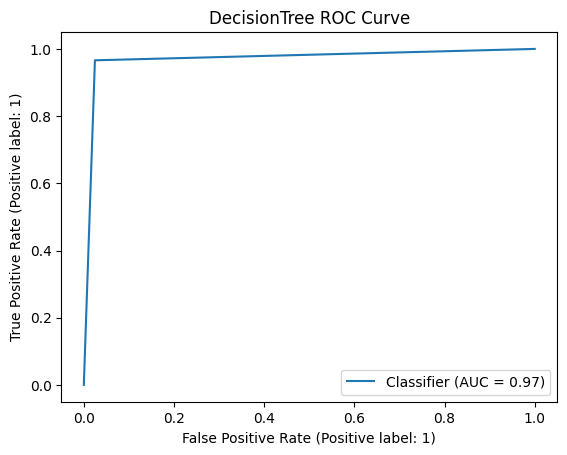

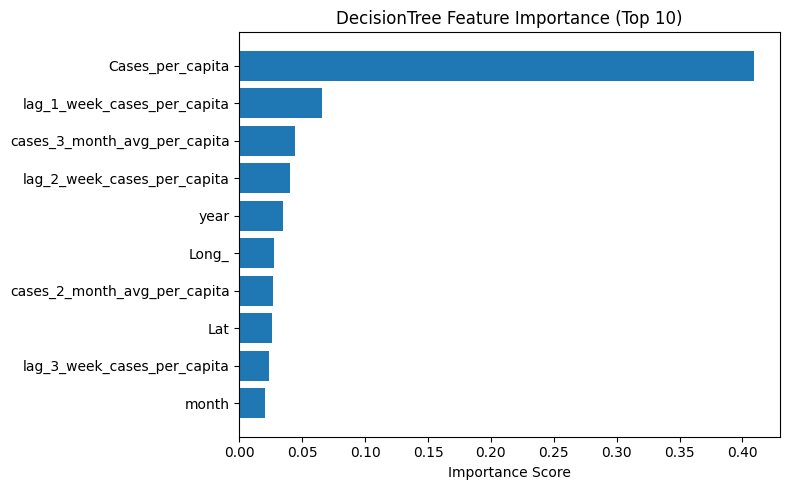


Training Bagging...

--- Bagging Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     60344
           1       0.98      0.97      0.98     44220

    accuracy                           0.98    104564
   macro avg       0.98      0.98      0.98    104564
weighted avg       0.98      0.98      0.98    104564



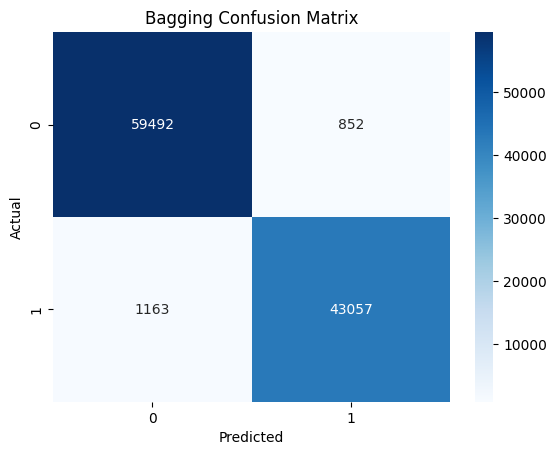

ROC AUC: 0.9961


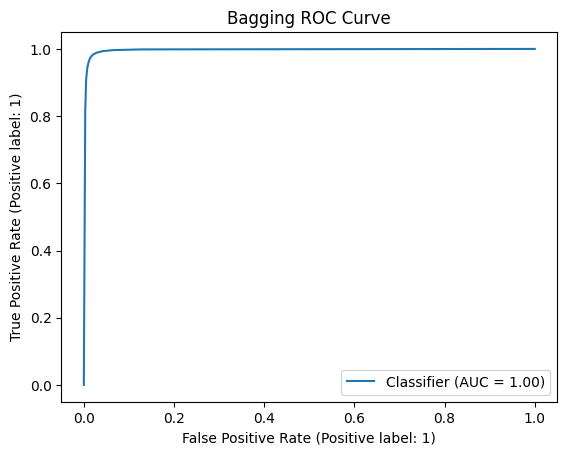

In [23]:
models = {
    'XGBoost': XGBClassifier(
        tree_method='hist',          # CPU-optimized tree method
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(     # CPU is default
        boosting_type='gbdt'
    ),
    'DecisionTree': DecisionTreeClassifier(),
    'Bagging': BaggingClassifier(
        estimator=DecisionTreeClassifier()
    )
}




def train_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model

def evaluate_model(name, model, X_test, y_test):
    print(f"\n--- {name} Evaluation ---")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        print(f"ROC AUC: {roc_auc:.4f}")
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"{name} ROC Curve")
        plt.show()

def plot_feature_importance(model, feature_names, name):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        sorted_idx = importances.argsort()[::-1]
        top_n = min(10, len(importances))
        plt.figure(figsize=(8, 5))
        plt.barh(
            [feature_names[i] for i in sorted_idx[:top_n]][::-1],
            importances[sorted_idx[:top_n]][::-1]
        )
        plt.title(f"{name} Feature Importance (Top {top_n})")
        plt.xlabel("Importance Score")
        plt.tight_layout()
        plt.show()

trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    trained = train_model(model, X_train, y_train)
    trained_models[name] = trained
    evaluate_model(name, trained, X_test, y_test)
    plot_feature_importance(trained, X_train.columns, name)